In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import numpy as np

In [4]:
nobel = pd.read_csv('nobel.csv')
nobel.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [5]:
nobel.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 911 entries, 0 to 910
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   year                  911 non-null    int64 
 1   category              911 non-null    object
 2   prize                 911 non-null    object
 3   motivation            823 non-null    object
 4   prize_share           911 non-null    object
 5   laureate_id           911 non-null    int64 
 6   laureate_type         911 non-null    object
 7   full_name             911 non-null    object
 8   birth_date            883 non-null    object
 9   birth_city            883 non-null    object
 10  birth_country         885 non-null    object
 11  sex                   885 non-null    object
 12  organization_name     665 non-null    object
 13  organization_city     667 non-null    object
 14  organization_country  667 non-null    object
 15  death_date            593 non-null    ob

The most commonly awarded gender is: Male


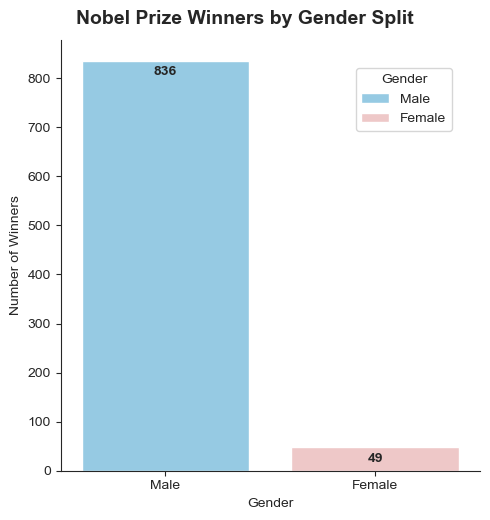

In [13]:
# Count awards for each gender and identify max
gender_count = nobel.value_counts("sex", dropna = False)
top_gender = gender_count.idxmax()
print(f"The most commonly awarded gender is: {top_gender}")
colours = ["#89CFF0", "#F4C2C2"]  
# Plot of gender split
sns.set_style("ticks")
g = sns.catplot(data = nobel, 
                x = "sex", 
                kind = "count", 
                hue = "sex",
                palette = colours,
                legend = False)
g.fig.suptitle("Nobel Prize Winners by Gender Split", 
               fontsize = 14, fontweight = "bold", 
               y = 1.03)
g.set_axis_labels("Gender", "Number of Winners") 

ax = g.ax
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        int(height),  # text
        (p.get_x() + p.get_width() / 2., (height - 12)),  
        ha = 'center', 
        va = 'top',  
        fontsize = 10,
        fontweight = 'bold',)

ax.legend(title ="Gender", # title
          labels = ["Male", "Female"], 
          bbox_to_anchor = (0.95, 0.95));

The decade with the highest ratio of US-born Nobel Prize winners to total winners in all categories is 2000.


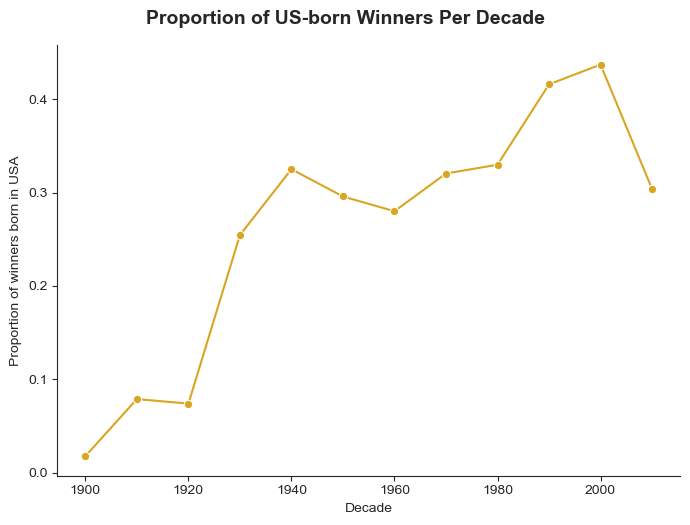

In [18]:
nobel["awardDecade"] = (nobel["year"] // 10) * 10

byDecade = nobel.groupby(["awardDecade", "birth_country"]).size().reset_index(name = "count")

usa_label = globals().get("top_country", None)

if usa_label is not None:
    usa = byDecade[byDecade["birth_country"] == usa_label]
else:
    candidates = ["United States of America", "United States", "USA", "U.S.A.", "US", "U.S."]
    mask = byDecade["birth_country"].isin(candidates) | byDecade["birth_country"].str.contains("United States", na=False)
    usa = byDecade[mask]


total = byDecade.groupby("awardDecade")["count"].sum().reset_index(name="count_all")


if not usa.empty:
    usa = usa.rename(columns={"count":"count_usa"})
    ratio_df = total.merge(usa[["awardDecade", "count_usa"]], on="awardDecade", how="left")
    ratio_df["count_usa"] = ratio_df["count_usa"].fillna(0).astype(int)
else:
    ratio_df = total.copy()
    ratio_df["count_usa"] = 0

ratio_df["usa_ratio"] = ratio_df["count_usa"] / ratio_df["count_all"]

if ratio_df["usa_ratio"].dropna().shape[0] == 0:
    print("No US-born winners found (birth_country labels may not match).")
else:
    if (ratio_df["usa_ratio"] > 0).any():
        max_usa_idx = ratio_df["usa_ratio"].idxmax()
        max_decade_usa = int(ratio_df.loc[max_usa_idx, "awardDecade"])
        print(f"The decade with the highest ratio of US-born Nobel Prize winners to total winners in all categories is {max_decade_usa}.")
    else:
        print("US-born winners exist in the data but all usa_ratio values are zero.")

g = sns.relplot(data = ratio_df.sort_values("awardDecade"), x = "awardDecade", y = "usa_ratio", 
                kind = "line", marker = "o", color = "goldenrod",
                aspect = 1.4)
g.fig.suptitle("Proportion of US-born Winners Per Decade", 
               fontsize = 14, fontweight = "bold",
               y = 1.04)
g.set_axis_labels("Decade", "Proportion of winners born in USA");

The first female laureate was Marie Curie, née Sklodowska, who recieved the Nobel Physics Prize


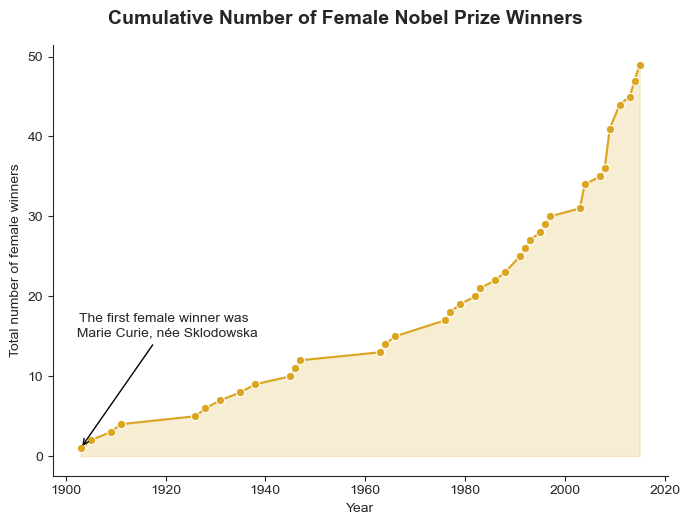

In [22]:
female_mask = nobel["sex"].str.lower() == "female"
nobel_female = nobel[female_mask].sort_values(by = "year")

if nobel_female.empty:
    print("No female laureates found in the data.")
else:
    nobel_first_woman = nobel_female.iloc[0, :]

    # Save their name and category
    first_woman_name = nobel_first_woman["full_name"]
    first_woman_category = nobel_first_woman["category"]
    print(f"The first female laureate was {first_woman_name}, who recieved the Nobel {first_woman_category} Prize")

    # Plot
    nobel_women_cumsum = (nobel_female
                          .groupby("year")
                          .size()
                          .cumsum()
                          .reset_index(name = "Cumulative"))

    g = sns.relplot(data = nobel_women_cumsum, x = "year", y = "Cumulative", 
                    kind = "line", marker = "o", color = "goldenrod",
                    aspect = 1.4)
    g.fig.suptitle("Cumulative Number of Female Nobel Prize Winners", 
                   fontsize = 14, fontweight = "bold",
                   y = 1.04)
    g.set_axis_labels("Year", "Total number of female winners")


    ax = g.ax
    # add shading under the line
    ax.fill_between(
        x = nobel_women_cumsum["year"],
        y1 = nobel_women_cumsum["Cumulative"],
        y2 = 0,
        color = "goldenrod",
        alpha = 0.2)
    # annotate first female winner
    ax.annotate(f"The first female winner was \n {first_woman_name}", 
                xy = (nobel_first_woman["year"], 1), 
                xytext = (1920, 15),
                arrowprops = {"arrowstyle": "->", "color": "k"},
                fontsize = 10, ha = "center");